In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_breast_cancer, fetch_california_housing
import matplotlib.pyplot as plt
from sklearn.compose import make_column_selector
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.datasets import make_blobs, make_circles
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA


In [ ]:
#exercicio de treino
create_data = {
    'TerrenoM2': [50, 100, 140, np.nan, 200, 250, 300],
    'quartos': [2, 3, 4, 2, np.nan, 5, 6],
    'localização': ['Suldeste', 'Norte', 'Norte', 'Noroeste', 'Sul', 'Suldeste', 'Sul'],
    'preço': [100.000, 140.000, 200.000, 175.000, 350.000, 400.000, 450.000]
}

df = pd.DataFrame(create_data)

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
df['TerrenoM2'] = imputer.fit_transform(df[['TerrenoM2']])
df['quartos'] = imputer.fit_transform(df[['quartos']])

column_transformer = ColumnTransformer(
    [('enconder', OneHotEncoder(), ['localização'])], # Changed from list to tuple here
    remainder='passthrough'
)

x = column_transformer.fit_transform(df.drop('preço', axis=1))


y = df['preço']

linear_regression = LinearRegression()
linear_regression.fit(x, y)

data_to_predict = pd.DataFrame({
    'TerrenoM2': [200, 150, 100, 150, 100, 150, 240],
    'quartos': [4, 3, 2, 3, 4, 2, 5],
    'localização': ['Sul', 'Noroeste', 'Norte', 'Noroeste', 'Sul', 'Norte', 'Sul']
})

transformed_data = column_transformer.transform(data_to_predict)
linear_predict = linear_regression.predict(transformed_data)

print(linear_predict)


In [ ]:

#exercicio
data_set = {
    'remedio': ['A', 'AB' ,'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'JK','K', 'L', 'M'],
    'colateral': ['alto', 'baixo', 'medio', 'baixo', 'alto', 'medio', 'baixo', 'alto', 'medio', 'baixo', 'alto', 'medio','alto', 'baixo', 'medio'],
    'nivel_efetividade_porcentagem': [20, np.nan, 60, 60, 30, 65, 50, 90, 20, 15, 50, np.nan,75, 40, 40],
    'passa': ['não', 'sim' ,'sim', 'sim', 'não', 'sim', 'sim', 'sim', 'não', 'não', 'não', 'não', 'sim', 'sim', 'não']
}

df = pd.DataFrame(data_set)

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
df['nivel_efetividade_porcentagem'] = imputer.fit_transform(df[['nivel_efetividade_porcentagem']])

column_transformer = ColumnTransformer(
    [('enconder', OneHotEncoder(), ['remedio', 'colateral'])],
    remainder='passthrough'
)

x = column_transformer.fit_transform(df.drop('passa', axis=1))

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['passa'])

logistic_regression =  LogisticRegression()
logistic_regression.fit(x, y)

#Dados para fazer a previsões

predictions_data_set = pd.DataFrame({
    'remedio': ['A', 'AB' ,'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'JK','K', 'L', 'M'],
    'colateral': ['baixo', 'alto', 'medio', 'baixo', 'alto', 'medio', 'baixo', 'alto', 'medio', 'baixo', 'alto', 'medio','alto', 'baixo', 'medio'],
    'nivel_efetividade_porcentagem': [30, 50, 60, 30, 40, 55, 60, 70, 30, 25, 30, 60, 30, 50, 60],
})

transform = column_transformer.transform(predictions_data_set)

predict = logistic_regression.predict(transform)
transform_predict = label_encoder.inverse_transform(predict)
print(transform_predict)

predictions_data_set['passa'] = transform_predict
print(predictions_data_set)


In [ ]:

#Exercício: Análise de Desempenho de Veículos Elétricos
conjunto_de_dados = pd.DataFrame({
    'fabricante': ['Tesla', 'BYD', 'Tesla', 'GM', 'Ford', 'BYD', 'Volkswagen', 'Rivian', 'Nissan', 'Hyundai', 'GM', 'Ford', 'Tesla', 'Volkswagen', 'Rivian'],
    'tipo_bateria': ['LFP', 'NMC', 'NMC', 'Ultium', 'LFP', 'LFP', 'NMC', 'NMC', 'LFP', 'NMC', 'Ultium', 'LFP', 'NMC', 'LFP', 'NMC'],
    'categoria_veiculo': ['sedan', 'SUV', 'SUV', 'pickup', 'SUV', 'sedan', 'hatch', 'SUV', 'hatch', 'SUV', 'pickup', 'SUV', 'sedan', 'hatch', 'pickup'],
    'capacidade_bateria_kmh':  [75, 85.5, 100, 200, 98, 72.5, 58, 180, 62, 77.4, 210, 91, 82, 55, 135],
    'potencia_motor_cv': [350, 310, 450, 400, 290, 280, 204, 415, 214, 305, 380, 285, 420, 190, 408],
    'autonomia_km': [550, 520, 610, 640, 490, 480, 380, 505, 385, 460, 660, 475, 580, 350, 510]
})

df = conjunto_de_dados

column_transform = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(), ['fabricante', 'tipo_bateria']),
        ('ordinal', OrdinalEncoder(categories=[['hatch', 'sedan', 'SUV', 'pickup']]), ['categoria_veiculo'])
        ],
        remainder='passthrough'
  )

x = column_transform.fit_transform(df.drop('autonomia_km', axis=1))
y = df['autonomia_km']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

regressor = LinearRegression()
regressor.fit(X_train, y_train)

x_pred = regressor.predict(X_test)
print("Predictions for X_test:", x_pred)

#mean absolute error e r2 score

score = mean_absolute_error(y_test, x_pred)
print("Mean Absolute Error:", score)
r2_score_value = r2_score(y_test, x_pred)
print("R2 Score:", r2_score_value)

dados_para_previsao = pd.DataFrame({
    'fabricante': ['Tesla', 'BYD', 'Ford', 'Hyundai', 'Rivian'],
    'tipo_bateria': ['NMC', 'LFP', 'LFP', 'NMC', 'NMC'],
    'categoria_veiculo': ['SUV', 'sedan', 'SUV', 'hatch', 'pickup'],
    'capacidade_bateria_kmh': [95, 78, 88, 65, 160],
    'potencia_motor_cv': [420, 295, 300, 220, 395]
})

dado_transformado = column_transform.transform(dados_para_previsao)

previsao = regressor.predict(dado_transformado)

print("Previsões: ")
print(previsao)

dados_para_previsao['autonomia_km'] = previsao
print(dados_para_previsao)

In [ ]:
#exercicio de treino
data_set = {
    'Nomes': ['João', 'Maria', 'Pedro', 'Ana', 'Carlos'],
    'Idade': [25, np.nan, 35, 40, np.nan],
    'Saúde': ['Saudavel', 'Doente', 'Intermediario', 'Saudavel', 'Doente'],
    'Risco': ['Baixo', 'Alto', 'Medio', 'Baixo', 'Alto']
}

df = pd.DataFrame(data_set)

preprocessador = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]),
      [ 'Idade']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['Nomes', 'Saúde'])
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessador),
    ('classifier', LogisticRegression())
])

x = df.drop('Risco', axis=1)
y = df['Risco']

pipeline.fit(x, y)

conjunto_de_dados = {
    'Nomes': ['Marta', 'John', 'Fred', 'Ari', 'Justin'],
    'Idade': [30, 21, 35, 20, 31],
    'Saúde': ['Doente', 'Saudavel', 'Doente', 'Intermediario', 'Saudavel']
}

novo_conjunto = pd.DataFrame(conjunto_de_dados)
predictions = pipeline.predict(novo_conjunto)
novo_conjunto['passa'] = predictions
print(novo_conjunto)



In [ ]:
#exercicio
conjunto_de_dados = {
    'remedio': ['A', 'AB' ,'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'JK','K', 'L', 'M'],
    'colateral': ['alto', 'baixo', 'medio', 'baixo', 'alto', 'medio', 'baixo', 'alto', 'medio', 'baixo', 'alto', 'medio','alto', 'baixo', 'medio'],
    'nivel_efetividade_porcentagem': [20, np.nan, 60, 60, 30, 65, 50, 90, 20, 15, 50, np.nan,75, 40, 40],
    'passa': ['não', 'sim' ,'sim', 'sim', 'não', 'sim', 'sim', 'sim', 'não', 'não', 'não', 'não', 'sim', 'sim', 'não']
}

df = pd.DataFrame(conjunto_de_dados)

preprocessamente = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]),
     ['nivel_efetividade_porcentagem']),
    ('cat', OneHotEncoder(), ['remedio', 'colateral'])
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessamente),
    ('classifier', LogisticRegression())
])

x = df.drop('passa', axis=1)
y =df['passa']

pipeline.fit(x, y)

previsoes_dados = pd.DataFrame({
    'remedio': ['A', 'AB' ,'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'JK','K', 'L', 'M'],
    'colateral': ['baixo', 'alto', 'medio', 'baixo', 'alto', 'medio', 'baixo', 'alto', 'medio', 'baixo', 'alto', 'medio','alto', 'baixo', 'medio'],
    'nivel_efetividade_porcentagem': [30, 50, 60, 30, 40, 55, 60, 70, 30, 25, 30, 60, 30, 50, 60],
})

predictions = pipeline.predict(previsoes_dados)
previsoes_dados['passa'] = predictions
print(previsoes_dados)


In [ ]:
from datetime import datetime, date
#Exercício: Sistema de Recomendação de Filmes
"""
Desafio Opcional
1 - Modifique o ColumnTransformer para usar MinMaxScaler em vez de StandardScaler nas features numéricas.

2 - Adicione uma feature de "idade do filme" (ano atual - ano_lancamento) antes da transformação.

3 -Experimente usar um modelo de RandomForestRegressor e compare os resultados.

"""
data_set_filmes = pd.DataFrame({
    'titulo': ['O Poderoso Chefão', 'Interestelar', 'Parasita', 'Cidade de Deus', 'Matrix', 'Clube da Luta', 'A Origem', 'O Senhor dos Anéis', 'Pulp Fiction', 'Coringa', 'Forrest Gump', 'Gladiador', 'Os Infiltrados', 'Seven', 'De Volta para o Futuro'],
    'genero': ['Drama', 'Ficção Científica', 'Thriller', 'Drama', 'Ficção Científica', 'Drama', 'Ficção Científica', 'Fantasia', 'Crime', 'Drama', 'Drama', 'Ação', 'Crime', 'Thriller', 'Ficção Científica'],
    'classificacao_etaria': ['18+', '12+', '16+', '18+', '14+', '18+', '14+', '12+', '18+', '16+', '12+', '16+', '16+', '18+', 'Livre'],
    'diretor': ['Coppola', 'Nolan', 'Bong', 'Meirelles', 'Wachowski', 'Fincher', 'Nolan', 'Jackson', 'Tarantino', 'Phillips', 'Zemeckis', 'Scott', 'Scorsese', 'Fincher', 'Zemeckis'],
    'duracao_minutos': [175, 169, 132, 130, 136, 139, 148, 178, 154, 122, 142, 155, 151, 127, 116],
    'orcamento_milhoes': [6, 165, 11, 3, 63, 63, 160, 93, 8, 55, 55, 103, 90, 33, 19],
    'ano_lancamento': [1972, 2014, 2019, 2002, 1999, 1999, 2010, 2001, 1994, 2019, 1994, 2000, 2006, 1995, 1985],
    'avaliacao_media': [9.2, 8.6, 8.6, 8.6, 8.7, 8.8, 8.8, 8.9, 8.9, 8.4, 8.8, 8.5, 8.5, 8.6, 8.5]
})

df = data_set_filmes

dia_atual = date.today()
ano_atual = dia_atual.year

df['idade_do_filme'] = ano_atual - df['ano_lancamento']

preprocessamento = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('scaler', MinMaxScaler())
        ]), ['duracao_minutos', 'orcamento_milhoes', 'ano_lancamento', 'idade_do_filme']),
        ('onehot', OneHotEncoder(handle_unknown='ignore'), ['genero', 'diretor']),
        ('ordinal', OrdinalEncoder(categories=[['Livre', '12+', '14+', '16+', '18+']]), ['classificacao_etaria'] )
    ], remainder = 'passthrough'
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessamento),
    ('regressor', LinearRegression())
])

pipeline2 = Pipeline(steps=[
    ('preprocessor', preprocessamento),
    ('regressor', RandomForestRegressor(max_depth=2, random_state=0))
])


x = df.drop(['avaliacao_media', 'titulo'], axis=1)
y = df['avaliacao_media']


X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)

pipeline2.fit(X_train, y_train)

print("Pipeline com LinearRegression")

x_pred = pipeline.predict(X_test)
print("Predictions for X_test:", x_pred)

print("Pipeline com RandomForestRegressor")

x_pred2 = pipeline2.predict(X_test)
print("Predictions for X_test:", x_pred2)

score = mean_squared_error(y_test, x_pred)
print("Mean Squared Error:", score)

r2_score_value = r2_score(y_test, x_pred)
print("R2 Score:", r2_score_value)




novos_filmes = pd.DataFrame({
    'titulo': ['Duna', '1917', 'O Irlandês'],
    'genero': ['Ficção Científica', 'Drama', 'Crime'],
    'classificacao_etaria': ['14+', '16+', '18+'],
    'diretor': ['Villeneuve', 'Mendes', 'Scorsese'],
    'duracao_minutos': [155, 119, 209],
    'orcamento_milhoes': [165, 95, 159],
    'ano_lancamento': [2021, 2019, 2019]
})

# Calculate 'idade_do_filme' for the new data as well
novos_filmes['idade_do_filme'] = ano_atual - novos_filmes['ano_lancamento']

predicoesPipeline = pipeline.predict(novos_filmes)
predicoesPipeline2 = pipeline2.predict(novos_filmes)

print("\nPipeline com LinearRegression")
print(predicoesPipeline, end='\n\n')

print("Pipeline com RandomForestRegressor")
print(predicoesPipeline2, end='\n\n')

#LR == Linear Regression RFR == Random Forest Regressor
novos_filmes['avaliacao_media_LR'] = predicoesPipeline
novos_filmes['avaliacao_media_RFR'] = predicoesPipeline2

print(novos_filmes)

In [ ]:

#Preços de carro | Apenas um exemplo
data = {
    'marca': ['Toyota', 'Honda', 'Ford', 'Chevrolet', 'Nissan', 'BMW', 'Mercedes-Benz', 'Audi', 'Volkswagen'],
    'ano_lançamento': [2013, 2014, 2007, 2023, 2010, 2005, 2025, 2024, 2012],
    'km_rodados': [100000, 90000, 130000, 30000, 98000, 150000, 450, 7000, 60000],
    'preco': [40000, 60000, 30000, 70000, 48000, 25000, 450000, 370000, 45000]
}

df = pd.DataFrame(data)

preprocessador = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('scaler', StandardScaler())
        ]), ['ano_lançamento', 'km_rodados']),
        ('enconder', OneHotEncoder(handle_unknown='ignore'), ['marca'])
    ], remainder='passthrough'
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessador),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

x = df.drop('preco', axis=1)
y = df['preco']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)

prediction_test = pipeline.predict(X_test)
print("\nPredições feitas: ")
print(prediction_test)
print("\nPredições corretas: ")
print(y_test)

mse = mean_squared_error(y_test, prediction_test)
print(f"Mean Squared Error: {mse:.2f}")

rmse = np.sqrt(mse)

print(f"RMSE: {rmse:.2f}")

r2 = r2_score(y_test, prediction_test)
print(f"R2 Score: {r2:.2f}")


In [ ]:
data = {
    'nome': ['joão', 'maria', 'pedro', 'ana', 'carlos', 'lucia', 'rafael', 'fernanda', 'roberto', 'juliana', 'marcos', 'beatriz', 'andre', 'camila', 'sergio'],
    'vendas': [2000, 1500, 1000, 2100, 1800, 2500, 1700, 2200, 1900, 2800, 1200, 2300, 1600, 2700, 1400],
    'dias_trabalhados': [24, 20, 15, 20, 18, 22, 19, 21, 17, 23, 16, 22, 18, 24, 15],
    'chance_de_promocao': ["alta", "baixa", "baixa", "alta", "media", "alta", "media", "alta", "media", "alta", "baixa", "alta", "baixa", "alta", "baixa"]
}
df = pd.DataFrame(data)

colunm_transformer =  ColumnTransformer(
    transformers=[
        ("num", Pipeline(
            steps=[("scaler", StandardScaler())]
        ), ['vendas', 'dias_trabalhados']),
        ('enconder', OneHotEncoder(handle_unknown='ignore'), ['nome'])
    ], remainder='passthrough')

pipeline = Pipeline(steps=[
    ("preprocessor", colunm_transformer),
    ("regressor", LogisticRegression())
])
x = df.drop(['chance_de_promocao'], axis=1)
y = LabelEncoder().fit_transform(df['chance_de_promocao'])

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, Y_train)

prediction_X_test = pipeline.predict(X_test)

#accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(Y_test, prediction_X_test)
precision = precision_score(Y_test, prediction_X_test, average='weighted')
recall = recall_score(Y_test, prediction_X_test, average='weighted')
f1 = f1_score(Y_test, prediction_X_test, average='weighted')

print("accuracy: ", accuracy)

print("precision: ", precision)

print("recall: ", recall)

print("f1: ", f1)


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

breast_cancer = load_breast_cancer(as_frame=True)

x = breast_cancer.data.head(50)
y = breast_cancer.target.head(50)

column_transformer = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("scaler", StandardScaler())]), make_column_selector(dtype_include=['int64', 'float64']))
    ], remainder='passthrough')

pipeline = Pipeline(steps=[
    ("preprocessor", column_transformer),
    ("classifier", LogisticRegression())
])

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print(f"Teve um recall de: {recall:.2f}")
print(f"Teve um precision de: {precision:.2f}")

scores = cross_val_score(pipeline, X_train, y_train, cv=4)
print("Scores: ", scores)
print("Score média: ", scores.mean())

print("\nMatriz de confusão\n")

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Maligno', 'Benigno'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão')
plt.show()

print("\nGráfico de probabilidades\n")
# Obter probabilidades previstas
y_proba = pipeline.predict_proba(X_test)[:, 1]  # Probabilidade da classe positiva

# Ordenar por probabilidade para visualização mais clara
sorted_idx = np.argsort(y_proba)

plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_test)), y_proba[sorted_idx],
         color='red', alpha=0.7, label='Probabilidade prevista')
plt.scatter(range(len(y_test)), y_test.iloc[sorted_idx],
            color='blue', alpha=0.5, label='Classe verdadeira', s=50)

plt.title('Probabilidades de Classificação')
plt.xlabel('Amostras (ordenadas por probabilidade)')
plt.ylabel('Probabilidade/Classe')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Limite de decisão (0.5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nGráfico com uma feature específica\n")
feature_to_plot = x.columns[0]  # Primeira feature

plt.figure(figsize=(10, 6))
plt.scatter(X_test[feature_to_plot], y_test, color="blue", label="Dados de teste", alpha=0.7, s=50)
plt.scatter(X_test[feature_to_plot], y_pred, color="red", label="Previsões", alpha=0.7, marker='x', s=100)

plt.title(f'Classificação - Feature: {feature_to_plot}')
plt.xlabel(feature_to_plot)
plt.ylabel('Classe (0=Maligno, 1=Benigno)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
california_housing = fetch_california_housing(as_frame=True)

x = california_housing.data.head(50)
y = california_housing.target.head(50)

pipeline = Pipeline(steps=[
    ("preprocessor", StandardScaler()),
    ("regressor", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)


pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2_score_value = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2_score_value:.2f}")

scores = cross_val_score(pipeline, X_train, y_train, cv=4)
print("\nScores: ", scores)
print("Score média: ", scores.mean(), "\n")
print("Graficos gerados: \n")


for i in range(len(x.columns)):
  feature_to_plot = x.columns[i]
  plt.scatter(X_test[feature_to_plot], y_test, color='blue', label='Valores reais')
  plt.scatter(X_test[feature_to_plot], y_pred, color='yellow', label="Valores previstos") # Line for perfect prediction
  plt.xlabel('Valores Reais (y_test)')
  plt.ylabel('Valores Preditos (y_pred)')
  plt.title(f'{feature_to_plot}')
  plt.legend()
  plt.grid(True)
  plt.show()
  print("\n\n")




In [ ]:
# Defining a simple dataset
attribute_names =  ['age', 'income','student', 'credit_rate']
class_name = 'default'
data1 ={
    'age' : ['youth', 'youth', 'middle_age', 'senior', 'senior', 'senior','middle_age', 'youth', 'youth', 'senior', 'youth', 'middle_age','middle_age', 'senior'],
    'income' : ['high', 'high', 'high', 'medium', 'low', 'low', 'low', 'medium','low', 'medium', 'medium', 'medium', 'high', 'medium'],
    'student' : ['no','no','no','no','yes','yes','yes','no','yes','yes','yes','no','yes','no'],
    'credit_rate' : ['fair', 'excellent', 'fair', 'fair', 'fair', 'excellent', 'excellent', 'fair', 'fair', 'fair','excellent', 'excellent', 'fair', 'excellent'],
    'default' : ['no', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'no', 'yes', 'yes','yes', 'yes', 'yes', 'no']
}
df1 = pd.DataFrame (data1, columns=data1.keys())
# STEP 1: Calculate gini(D)
def gini_impurity (value_counts):
    n = value_counts.sum()
    p_sum = 0

    for key in value_counts.keys():
        p_sum = p_sum  +  (value_counts[key] / n ) * (value_counts[key] / n )
    gini = 1 - p_sum
    return gini

class_value_counts = df1[class_name].value_counts()
print(f'Number of samples in each class is:\n{class_value_counts}')

gini_class = gini_impurity(class_value_counts)
print(f'\nGini Impurity of the class is {gini_class:.3f}')

# STEP 2:
# Calculating  gini impurity for the attiributes
def gini_split_a(attribute_name):
    attribute_values = df1[attribute_name].value_counts()
    gini_A = 0
    for key in attribute_values.keys():
        df_k = df1[class_name][df1[attribute_name] == key].value_counts()
        n_k = attribute_values[key]
        n = df1.shape[0]
        gini_A = gini_A + (( n_k / n) * gini_impurity(df_k))
    return gini_A

gini_attiribute ={}
for key in attribute_names:
    gini_attiribute[key] = gini_split_a(key)
    print(f'Gini for {key} is {gini_attiribute[key]:.3f}')

# STEP 3:
# Compute Gini gain values to find the best split
# An attribute has maximum Gini gain is selected for splitting.

min_value = min(gini_attiribute.values())
print('The minimum value of Gini Impurity : {0:.3} '.format(min_value))
print('The maximum value of Gini Gain     : {0:.3} '.format(1-min_value))

selected_attribute = min(gini_attiribute.keys())
print('The selected attiribute is: ', selected_attribute)

In [ ]:
# Defining a simple dataset
attribute_names =  ['age', 'income','student', 'credit_rate']
class_name = 'default'
data1 ={
    'age' : ['youth', 'youth', 'middle_age', 'senior', 'senior', 'senior','middle_age', 'youth', 'youth', 'senior', 'youth', 'middle_age','middle_age', 'senior'],
    'income' : ['high', 'high', 'high', 'medium', 'low', 'low', 'low', 'medium','low', 'medium', 'medium', 'medium', 'high', 'medium'],
    'student' : ['no','no','no','no','yes','yes','yes','no','yes','yes','yes','no','yes','no'],
    'credit_rate' : ['fair', 'excellent', 'fair', 'fair', 'fair', 'excellent', 'excellent', 'fair', 'fair', 'fair','excellent', 'excellent', 'fair', 'excellent'],
    'default' : ['no', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'no', 'yes', 'yes','yes', 'yes', 'yes', 'no']
}
df1 = pd.DataFrame (data1, columns=data1.keys())

x = df1.drop('default', axis=1)
y = df1['default']

column_transformer = ColumnTransformer(
    transformers=[
         ("enconder", OneHotEncoder(handle_unknown='ignore'), ['age', 'income', 'student', 'credit_rate'])
    ], remainder='passthrough'
)

pipeline = Pipeline(steps=[
    ("preprocessor", column_transformer),
    ("classifier", DecisionTreeClassifier())
])

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"{accuracy:.2f}")

recall = recall_score(y_test, y_pred, pos_label='yes')

print(f"{recall:.2f}")

precision = precision_score(y_test, y_pred, pos_label='yes')

print(f"{precision:.2f}")

# Get the feature names after one-hot encoding
ohe_feature_names = pipeline.named_steps['preprocessor'].named_transformers_['enconder'].get_feature_names_out()
print(ohe_feature_names)
plt.figure(figsize=(10, 10))
plot_tree(pipeline['classifier'], feature_names=ohe_feature_names.tolist(), class_names=pipeline['classifier'].classes_.tolist(), filled=True, rounded=True)
plt.plot()

In [ ]:
# Defining a simple dataset
attribute_names =  ['age', 'income','student', 'credit_rate']
class_name = 'default'
data1 ={
    'age' : ['youth', 'youth', 'middle_age', 'senior', 'senior', 'senior','middle_age', 'youth', 'youth', 'senior', 'youth', 'middle_age','middle_age', 'senior'],
    'income' : ['high', 'high', 'high', 'medium', 'low', 'low', 'low', 'medium','low', 'medium', 'medium', 'medium', 'high', 'medium'],
    'student' : ['no','no','no','no','yes','yes','yes','no','yes','yes','yes','no','yes','no'],
    'credit_rate' : ['fair', 'excellent', 'fair', 'fair', 'fair', 'excellent', 'excellent', 'fair', 'fair', 'fair','excellent', 'excellent', 'fair', 'excellent'],
    'default' : ['no', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'no', 'yes', 'yes','yes', 'yes', 'yes', 'no']
}
df1 = pd.DataFrame (data1, columns=data1.keys())

x = df1.drop('default', axis=1)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df1['default'])

column_transformer = ColumnTransformer(
    transformers=[
         ("enconder", OneHotEncoder(handle_unknown='ignore'), ['age', 'income', 'student', 'credit_rate'])
    ], remainder='passthrough'
)

pipeline = Pipeline(steps=[
    ("preprocessor", column_transformer),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42)) # Changed to RandomForestClassifier
])

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"{accuracy:.2f}")

# For recall and precision, we use the numerical representation of 'yes'
recall = recall_score(y_test, y_pred, pos_label=label_encoder.transform(['yes'])[0])

print(f"{recall:.2f}")

precision = precision_score(y_test, y_pred, pos_label=label_encoder.transform(['yes'])[0])

print(f"{precision:.2f}")

# Get the feature names after one-hot encoding
ohe_feature_names = pipeline.named_steps['preprocessor'].named_transformers_['enconder'].get_feature_names_out()
print(ohe_feature_names)
plt.figure(figsize=(10, 10))

tree_to_plot = pipeline['classifier'].estimators_[0]

# For plot_tree, class_names should be the original string labels
plot_tree(tree_to_plot, feature_names=ohe_feature_names.tolist(), class_names=label_encoder.classes_.tolist(), filled=True, rounded=True)
plt.plot()

In [ ]:

X, y = make_circles(n_samples=200, factor=0.1, noise=0.5)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.figure(figsize=(10, 10))

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.title('Dataset de Exemplo')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

print("\n\n")

model = SVC(kernel='rbf', gamma='auto')
model.fit(X_train, y_train)

plt.figure(figsize=(10, 10))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')

xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 500), np.linspace(-2.5, 2.5, 500))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.75, cmap='viridis')
plt.title("Fronteira de Decisão com SVM e Kernel RBF")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
#Versão "otimizada" do exemplo anterior feito pelo deep import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report

# Gerar dados
X, y = make_circles(n_samples=200, factor=0.1, noise=0.5, random_state=42)

# Dividir dados
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Visualizar dados originais
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', s=50)
plt.title('Dados Originais')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Criar pipeline com padronização
pipeline = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf')
)

# Definir grade de hiperparâmetros para otimização
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': [0.01, 0.1, 1, 10, 'scale', 'auto']
}

# Busca em grade para melhores parâmetros
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Melhores parâmetros encontrados:")
print(f"C: {grid_search.best_params_['svc__C']}")
print(f"Gamma: {grid_search.best_params_['svc__gamma']}")
print(f"Melhor score de validação: {grid_search.best_score_:.3f}")

# Treinar modelo com melhores parâmetros
best_model = grid_search.best_estimator_

# Avaliar modelo
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia no teste: {accuracy:.3f}")
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred))

# Visualizar fronteira de decisão com dados de treino
plt.subplot(1, 3, 2)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis',
            edgecolors='k', s=50, alpha=0.7)

# Criar malha para visualização
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 500),
    np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 500)
)

# Prever para cada ponto da malha
Z = best_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.contour(xx, yy, Z, colors='black', linewidths=0.5, alpha=0.5)
plt.title(f"Fronteira de Decisão (C={grid_search.best_params_['svc__C']})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Visualizar com dados de teste
plt.subplot(1, 3, 3)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis',
            edgecolors='k', s=50, alpha=0.7)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.contour(xx, yy, Z, colors='black', linewidths=0.5, alpha=0.5)

# Destacar erros de classificação
y_test_pred = best_model.predict(X_test)
errors = X_test[y_test != y_test_pred]
if len(errors) > 0:
    plt.scatter(errors[:, 0], errors[:, 1],
                color='red', s=200, marker='x', linewidths=2,
                label=f'Erros ({len(errors)})')

plt.title(f"Teste - Acurácia: {accuracy:.3f}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
if len(errors) > 0:
    plt.legend()

plt.tight_layout()
plt.show()

# Versão alternativa: usar kernel polinomial para comparação
print("\n" + "="*60)
print("Comparação com Kernel Polinomial")
print("="*60)

# Pipeline com kernel polinomial
poly_pipeline = make_pipeline(
    StandardScaler(),
    SVC(kernel='poly')
)

# Grid para kernel polinomial
poly_param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__degree': [2, 3, 4],
    'svc__coef0': [0, 1, 2]
}

poly_grid = GridSearchCV(
    poly_pipeline,
    poly_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
poly_grid.fit(X_train, y_train)

print(f"\nMelhor kernel polinomial - Acurácia: {poly_grid.best_score_:.3f}")
print(f"Grau: {poly_grid.best_params_['svc__degree']}")
print(f"C: {poly_grid.best_params_['svc__C']}")

"""
ler mais sobre svc, OvO, OvR
"""

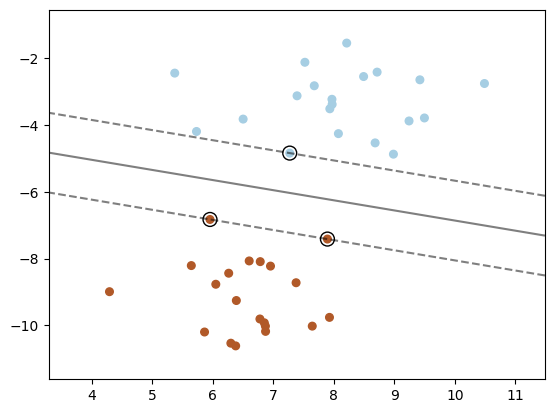

In [ ]:
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs
from sklearn.inspection import DecisionBoundaryDisplay
#tentar entender o parametros e esse codigo
# we create 40 separable points
X, y = make_blobs(n_samples=40, centers=2, random_state=6)

# fit the model, don't regularize for illustration purposes
clf = svm.SVC(kernel="linear", C=1000)
clf.fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)

# plot the decision function
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    plot_method="contour",
    colors="k",
    levels=[-1, 0, 1],
    alpha=0.5,
    linestyles=["--", "-", "--"],
    ax=ax,
)
# plot support vectors
ax.scatter(
    clf.support_vectors_[:, 0],
    clf.support_vectors_[:, 1],
    s=100,
    linewidth=1,
    facecolors="none",
    edgecolors="k",
)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs
from sklearn.inspection import DecisionBoundaryDisplay

# criar 40 pontos separáveis
X, y = make_blobs(n_samples=40, centers=2, random_state=6)

# ajustar o modelo
clf = svm.LinearSVC(C=1000, random_state=42)  # adicionado random_state para reprodutibilidade
clf.fit(X, y)

plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)

# plotar a função de decisão
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    plot_method="contour",
    colors="k",
    levels=[-1, 0, 1],
    alpha=0.5,
    linestyles=["--", "-", "--"],
    ax=ax,
)

# Encontrar os pontos mais próximos da fronteira de decisão
# Para LinearSVC, podemos calcular as distâncias à fronteira
decision_function = clf.decision_function(X)

# Encontrar os pontos com menor valor absoluto na função de decisão (mais próximos da fronteira)
abs_decision = abs(decision_function)
# Selecionar os 4 pontos mais próximos da fronteira como "vetores de suporte aproximados"
support_indices = abs_decision.argsort()[:4]
print("X support_indices: ", X[support_indices, 0])
# Plotar os pontos mais próximos da fronteira (aproximação dos vetores de suporte)
ax.scatter(
    X[support_indices, 0],
    X[support_indices, 1],
    s=200,  # tamanho maior para destacar
    linewidth=2,
    facecolors="none",
    edgecolors="red",
    label="Pontos próximos da fronteira"
)

plt.title("LinearSVC - Fronteira de Decisão Linear")
plt.legend()
plt.show()

# Informações adicionais para entender o modelo
print(f"Coeficientes: {clf.coef_}")
print(f"Intercepto: {clf.intercept_}")
print(f"Pontos selecionados como próximos da fronteira: {support_indices}")

In [ ]:
#unbalanced classes

import matplotlib.lines as mlines
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.datasets import make_blobs
from sklearn.inspection import DecisionBoundaryDisplay

# we create two clusters of random points
n_samples_1 = 1000
n_samples_2 = 100
centers = [[0.0, 0.0], [2.0, 2.0]]
clusters_std = [1.5, 0.5]
X, y = make_blobs(
    n_samples=[n_samples_1, n_samples_2],
    centers=centers,
    cluster_std=clusters_std,
    random_state=0,
    shuffle=False,
)


# Visualizando os primeiros samples
print("Primeiros 5 samples:")
for i in range(5):
    print(f"Sample {i}: X = {X[i]} (coordenadas), y = {y[i]} (classe)")

# fit the model and get the separating hyperplane
clf = svm.SVC(kernel="linear", C=1.0)
clf.fit(X, y)

# fit the model and get the separating hyperplane using weighted classes
wclf = svm.SVC(kernel="linear", class_weight={1: 10})
wclf.fit(X, y)

# plot the samples
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, edgecolors="k")

# plot the decision functions for both classifiers
ax = plt.gca()
disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    plot_method="contour",
    colors="k",
    levels=[0],
    alpha=0.5,
    linestyles=["-"],
    ax=ax,
)

# plot decision boundary and margins for weighted classes
wdisp = DecisionBoundaryDisplay.from_estimator(
    wclf,
    X,
    plot_method="contour",
    colors="r",
    levels=[0],
    alpha=0.5,
    linestyles=["-"],
    ax=ax,
)

plt.legend(
    [
        mlines.Line2D([], [], color="k", label="non weighted"),
        mlines.Line2D([], [], color="r", label="weighted"),
    ],
    ["non weighted", "weighted"],
    loc="upper right",
)
plt.show()

In [ ]:
#https://scikit-learn.org/stable/modules/svm.html#svm-mathematical-formulation
#1.4.1.3. Unbalanced problems

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import make_classification
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC

X, y = make_classification(
    n_samples=1_000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.1,
    weights=[0.9, 0.1],
    random_state=0,
)
# down-sample for plotting
rng = np.random.RandomState(0)
plot_indices = rng.choice(np.arange(X.shape[0]), size=100, replace=True)
X_plot, y_plot = X[plot_indices], y[plot_indices]


def plot_decision_function(classifier, sample_weight, axis, title):
    """Plot the synthetic data and the classifier decision function. Points with
    larger sample_weight are mapped to larger circles in the scatter plot."""
    axis.scatter(
        X_plot[:, 0],
        X_plot[:, 1],
        c=y_plot,
        s=100 * sample_weight[plot_indices],
        alpha=0.9,
        cmap=plt.cm.bone,
        edgecolors="black",
    )
    DecisionBoundaryDisplay.from_estimator(
        classifier,
        X_plot,
        response_method="decision_function",
        alpha=0.75,
        ax=axis,
        cmap=plt.cm.bone,
    )
    axis.axis("off")
    axis.set_title(title)


# we define constant weights as expected by the plotting function
sample_weight_constant = np.ones(len(X))
# assign random weights to all points
sample_weight_modified = abs(rng.randn(len(X)))
# assign bigger weights to the positive class
positive_class_indices = np.asarray(y == 1).nonzero()[0]
sample_weight_modified[positive_class_indices] *= 15

# This model does not include sample weights.
clf_no_weights = SVC(gamma=1)
clf_no_weights.fit(X, y)

# This other model includes sample weights.
clf_weights = SVC(gamma=1)
clf_weights.fit(X, y, sample_weight=sample_weight_modified)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_decision_function(
    clf_no_weights, sample_weight_constant, axes[0], "Constant weights"
)
plot_decision_function(clf_weights, sample_weight_modified, axes[1], "Modified weights")

plt.show()

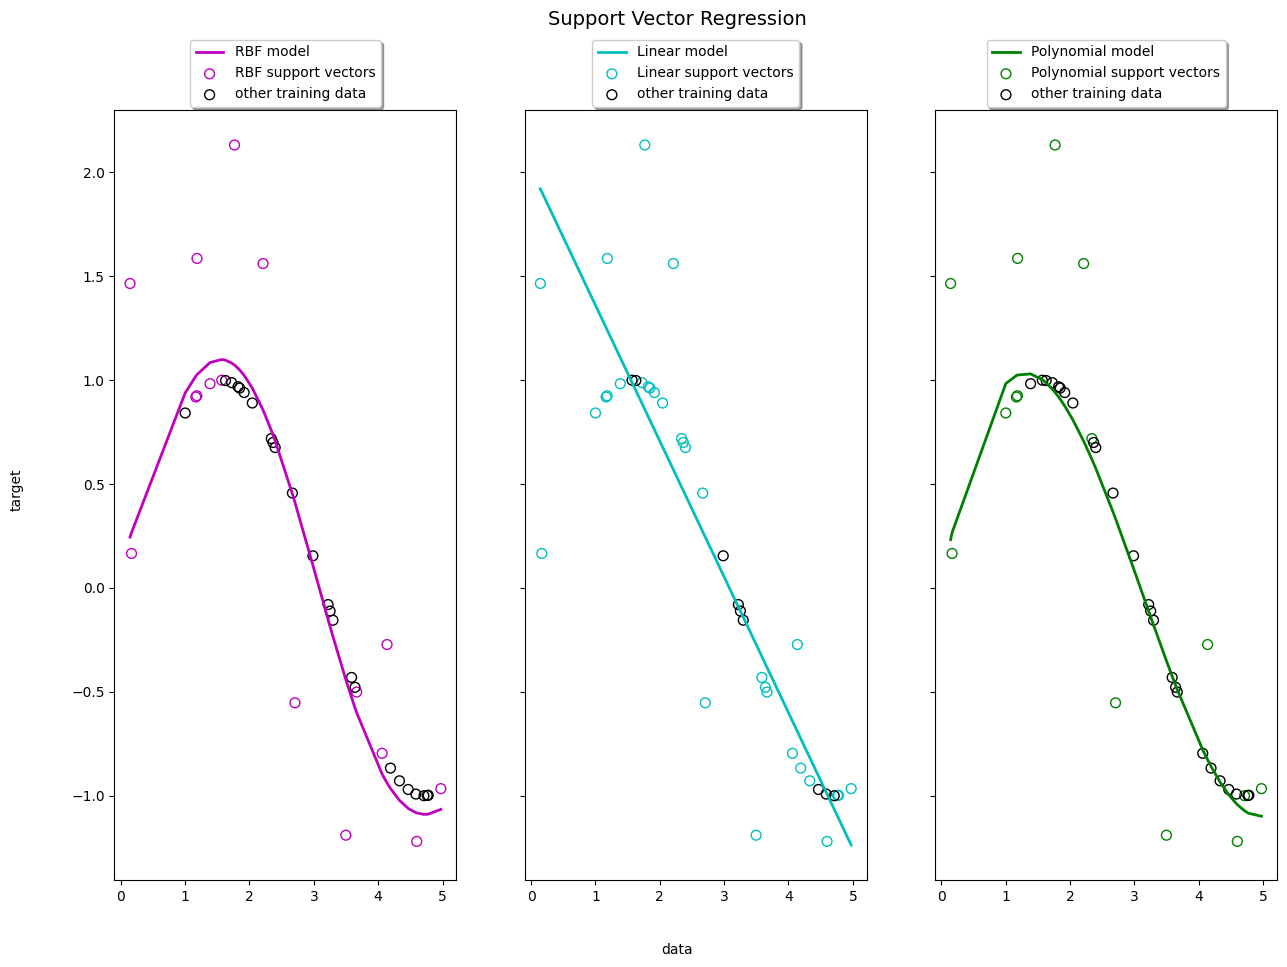

In [ ]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np

from sklearn.svm import SVR

X = np.sort(5 * np.random.rand(40, 1), axis=0)
y = np.sin(X).ravel()

# add noise to targets
y[::5] += 3 * (0.5 - np.random.rand(8))

svr_rbf = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1)
svr_lin = SVR(kernel="linear", C=100, gamma="auto")
svr_poly = SVR(kernel="poly", C=100, gamma="auto", degree=3, epsilon=0.1, coef0=1)

lw = 2

svrs = [svr_rbf, svr_lin, svr_poly]
kernel_label = ["RBF", "Linear", "Polynomial"]
model_color = ["m", "c", "g"]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 10), sharey=True)
for ix, svr in enumerate(svrs):
    axes[ix].plot(
        X,
        svr.fit(X, y).predict(X),
        color=model_color[ix],
        lw=lw,
        label="{} model".format(kernel_label[ix]),
    )
    axes[ix].scatter(
        X[svr.support_],
        y[svr.support_],
        facecolor="none",
        edgecolor=model_color[ix],
        s=50,
        label="{} support vectors".format(kernel_label[ix]),
    )
    axes[ix].scatter(
        X[np.setdiff1d(np.arange(len(X)), svr.support_)],
        y[np.setdiff1d(np.arange(len(X)), svr.support_)],
        facecolor="none",
        edgecolor="k",
        s=50,
        label="other training data",
    )
    axes[ix].legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.1),
        ncol=1,
        fancybox=True,
        shadow=True,
    )

fig.text(0.5, 0.04, "data", ha="center", va="center")
fig.text(0.06, 0.5, "target", ha="center", va="center", rotation="vertical")
fig.suptitle("Support Vector Regression", fontsize=14)
plt.show()

In [ ]:
#tentar fazer uns exercicio para entender melhor sobre svm, ovo ovr

In [ ]:

x, y = make_circles(n_samples=200, factor=0.5, noise=0.09)

x_train, x_test, y_train, y_test  = train_test_split(x, y, test_size=0.3, random_state=42)

plt.figure(figsize=(10, 8))
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.title("Dados Não Separaveis Linearmente")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

model = SVC(kernel='rbf', gamma='auto')
model.fit(x_train, y_train)

plt.figure(figsize=(10, 8))
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='viridis', edgecolors='k')

xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 550), np.linspace(-1.5, 1.5, 550))


Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.title("Fronteira de Decisão com SVM e Kernel RBF")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

predict = model.predict(x_test)
# The line 'predict = predict.reshape(x_test.shape)' caused the ValueError.
# It tried to reshape a 1D array of predictions (e.g., [0, 1, 0, ...]) into a 2D array
# with the shape of x_test (e.g., (40, 2)), which is incorrect because the number
# of elements (40) doesn't match (40 * 2 = 80).

# To visualize the predictions for the test set, we can plot the decision boundary again
# and then overlay the test points, colored by their predicted labels.
print("\n\n")
plt.figure(figsize=(10, 8))
# Plot the decision boundary using the previously calculated xx, yy, Z
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

# Plot the test data points, colored by their *predicted* classes
plt.scatter(x_test[:, 0], x_test[:, 1], c=predict, cmap='viridis', edgecolors='black', linewidth=1, s=80, label='Test points (predicted)')

# Optionally, plot the true labels for comparison (e.g., with a different marker or border)
# This helps to visually identify misclassified points.
plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test, cmap='viridis', edgecolors='red', marker='o', s=30, label='Test points (true)')

plt.title("Fronteira de Decisão com SVM e Kernel RBF (Test Predictions)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [ ]:

x, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.5)

plt.figure(figsize=(10, 8))
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.title("Dados Separaveis Linearmente")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


model = SVC(kernel='linear', gamma='auto')
model.fit(x, y)
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='viridis', edgecolors='k')

#por que com essa linha não da certo fazer o margem entre os dados
#xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 450), np.linspace(-1.5, 1.5, 450))
#e com essas sim
x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                      np.arange(y_min, y_max, 0.1))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.title("Dados Separaveis Linearmente 2")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


In [ ]:

# Gerar dados
x, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.5)

# Escalonar
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Treinar modelo com dados escalonados
model = SVC(kernel='linear', gamma='auto')
model.fit(x_scaled, y)

# Plot
plt.figure(figsize=(10, 8))

# Plotar dados escalonados
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=y, cmap='viridis', edgecolors='k')

# Criar malha para dados escalonados (agora em escala padrão)
xx, yy = np.meshgrid(np.linspace(-3, 3, 450),
                     np.linspace(-3, 3, 450))

# Fazer previsões
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.title("SVM com Dados Escalonados")
plt.xlabel("X (escalonado)")
plt.ylabel("Y (escalonado)")
plt.show()

##

model.fit(x, y)

# Plot
plt.figure(figsize=(10, 8))

# Plotar dados escalonados
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='viridis', edgecolors='k')

margin = 0.1  # 10% de margem
x_margin = (x[:, 0].max() - x[:, 0].min()) * margin
y_margin = (x[:, 1].max() - x[:, 1].min()) * margin

# Ou de forma mais automática:
x_min, x_max = x[:, 0].min() - x_margin, x[:, 0].max() + x_margin
y_min, y_max = x[:, 1].min() - y_margin, x[:, 1].max() + y_margin
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 450),
                     np.linspace(y_min, y_max, 450))
# Fazer previsões
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.title("SVM com Dados Escalonados")
plt.xlabel("X (escalonado)")
plt.ylabel("Y (escalonado)")
plt.show()

In [ ]:

x, y = make_blobs(n_samples=200, centers=2, random_state=42, cluster_std=1.5)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

svc = SVC(kernel='linear', gamma='auto')
svc.fit(x_scaled, y)

plt.figure(figsize=(10, 10))

plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=y, cmap='viridis', edgecolor='k')

#fazendo uma matriz 400x400, numeros de -3 a 3
xx, yy = np.meshgrid(np.linspace(-3, 3, 400), np.linspace(-3, 3, 400))
#transformadados a matriz em um array unimendicional
xx_ravel = xx.ravel()
yy_ravel = yy.ravel()
#pegamos as linhas criadas com xx ravel e yy ravel e transformados em uma matriz com duas colunas
grid = np.c_[xx_ravel, yy_ravel]
Z = svc.predict(grid)
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.title("SVM com Dados Escalonados")
plt.xlabel("X (escalonado)")
plt.ylabel("Y (escalonado)")
plt.show()

##

svc.fit(x, y)

plt.figure(figsize=(10, 10))

plt.scatter(x[:, 0], x[:, 1], c=y, cmap='viridis', edgecolor='k')

margin = 0.1
x_margin = (x[:, 0].max() - x[:, 0].min()) * margin
y_margin = (x[:, 1].max() - x[:, 1].min()) * margin

xx_min, xx_max = x[:, 0].min() - x_margin, x[:, 0].max() + x_margin
yy_min, yy_man = x[:, 1].min() - y_margin, x[:, 1].max() + y_margin

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(yy_min, yy_man, 400))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = svc.predict(grid)
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.title("SVM com Dados Escalonados")
plt.xlabel("X (escalonado)")
plt.ylabel("Y (escalonado)")
plt.show()



In [ ]:
x, y = np.linspace(-3, 3, 5), np.linspace(-3, 3, 5)
xx, yy = np.meshgrid(x, y)
print(xx)
print()
print(yy)

xx_ravel = xx.ravel()
yy_ravel = yy.ravel()

np_c = np.c_[xx_ravel, yy_ravel]
print(np_c)

margin_x = (xx[:, 0].min() - xx[:, 0].max()) * 0.1
margin_y = (xx[:, 1].min() - xx[:, 1].max()) * 0.1

xx_min, xx_max = xx[:, 0].min() - margin_x, xx[:, 0].max() + margin_x
yy_min, yy_max = xx[:, 0].min() - margin_y, xx[:, 0].max() + margin_y

print(xx_min, xx_max)
print(yy_min, yy_max)


In [ ]:

x, y = make_blobs(n_samples=200, centers=3, random_state=42, cluster_std=1.5)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

plt.figure(figsize=(8, 8))

plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=y, cmap='viridis', edgecolor='k')

model_ovr = OneVsRestClassifier(SVC(kernel='linear', probability=True)).fit(x_scaled, y)
model_ovo = OneVsOneClassifier(SVC(kernel='linear', probability=True)).fit(x_scaled, y)

svc = SVC()
svc.fit(x_scaled, y)

plt.figure(figsize=(8, 8))

plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=y, cmap='viridis', edgecolor='k')

#fazendo uma matriz 400x400, numeros de -3 a 3
xx, yy = np.meshgrid(np.linspace(-3, 3, 400), np.linspace(-3, 3, 400))
#transformadados a matriz em um array unimendicional
xx_ravel = xx.ravel()
yy_ravel = yy.ravel()
#pegamos as linhas criadas com xx ravel e yy ravel e transformados em uma matriz com duas colunas
grid = np.c_[xx_ravel, yy_ravel]
Z = model_ovr.predict(grid)
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.title("SVM com Dados Escalonados")
plt.xlabel("X (escalonado)")
plt.ylabel("Y (escalonado)")
plt.show()

Exercício: Classificação de Flores Iris

Contexto:
A base de dados Iris é clássica para aprendizado de máquina. Ela contém medidas de 150 flores de três espécies diferentes de Iris: Iris-setosa, Iris-versicolor e Iris-virginica. As características são: comprimento da sépala (cm), largura da sépala (cm), comprimento da pétala (cm) e largura da pétala (cm).

Objetivo:
Construa um modelo de classificação usando SVC para prever a espécie de uma flor Iris com base em suas medidas.

Tarefas:

Carregar e explorar os dados:

Carregue o dataset Iris (disponível em bibliotecas como scikit-learn).

Verifique a estrutura dos dados: quantas amostras, features e classes.

Divida os dados em features (X) e target (y).

Pré-processamento:

Divida os dados em conjuntos de treino e teste (ex: 70% treino, 30% teste). Use uma semente para reprodutibilidade.

Padronize os dados (recomendado para SVC) para que todas as features tenham média 0 e desvio padrão 1. Aplique a transformação nos dados de treino e teste separadamente para evitar data leakage.

Modelagem:

Inicialize um classificador SVC com kernel linear (para começar). Use os parâmetros padrão ou ajuste a regularização (C) se necessário.

Treine o modelo com os dados de treino padronizados.

Avaliação:

Faça previsões no conjunto de teste.

Calcule a acurácia do modelo.

Exiba uma matriz de confusão para analisar os erros.

Experimentação (opcional):

Teste diferentes kernels (ex: RBF, polinomial) e valores de hiperparâmetros (como C e gamma).

Compare os resultados com o kernel linear.

Desafio adicional (se quiser ir além):

Use apenas duas features (ex: comprimento e largura da pétala) para treinar o modelo e visualize a fronteira de decisão do SVC em um gráfico 2D. Isso ajuda a entender como o algoritmo está separando as classes.

Dica:
Lembre-se de que o SVC é originalmente binário, mas o scikit-learn já implementa a versão multiclasse automaticamente (usando one-vs-one ou one-vs-rest).

Acurácia do Modelo: 1.00
Matriz de Confusão (array):
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


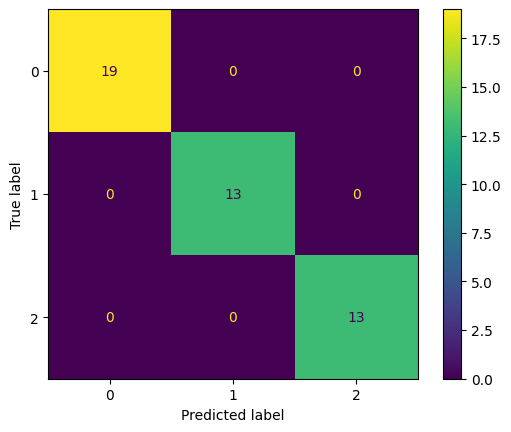

In [ ]:

from sklearn.datasets import load_iris
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

loadf_data = load_iris(as_frame=True)
x = loadf_data.data
y = loadf_data.target

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

#Padronize os dados (recomendado para SVC) para que todas as features tenham média 0 e desvio padrão 1. Aplique a transformação nos dados de treino e teste separadamente para evitar data leakage.
column_transformer = ColumnTransformer(
    transformers=[
        ("num", Pipeline(
            steps=[
                ("scaler", StandardScaler())
            ]
        ), ["sepal length (cm)", "sepal width (cm)", "petal length (cm)",  "petal width (cm)"]) # Corrected column names
    ]
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", column_transformer),
        ("classifier", OneVsRestClassifier(SVC(kernel='rbf', probability=True)))
    ]
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia do Modelo: {accuracy:.2f}")

#Exiba uma matriz de confusão para analisar os erros.
# Calcular a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

print("Matriz de Confusão (array):\n", cm)

# Visualizar a matriz de confusão, continuar o exerc, entender como a matriz confusão funciona
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
disp.plot()
plt.show()



In [ ]:

print("Visualizando os dados")
plt.figure(figsize=(10, 8))
plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=y, cmap='viridis', edgecolor='k', s=100)
plt.title("Conjunto de Dados Sintético")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
target_names = loadf_data.target_names
x = loadf_data.data.drop(columns=["petal length (cm)",  "petal width (cm)"])
def creating_grafic(X_df, y_series, trained_pipeline, title):
  # Convert DataFrame to NumPy array for numerical indexing for plot limits
  X_np = X_df.values

  # Adjust plot limits based on the data range of the original (unscaled) data
  x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
  y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5

  # Create a meshgrid for decision boundary plotting
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))

  # Create a DataFrame for the grid points, using the original column names
  # This ensures the ColumnTransformer inside the pipeline processes them correctly
  grid_df = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X_df.columns)

  # Predict using the full pipeline, which includes preprocessing (scaling)
  Z_predicted = trained_pipeline.predict(grid_df)
  Z_reshaped = Z_predicted.reshape(xx.shape) # Reshape the predictions to 2D

  plt.figure(figsize=(10, 8))
  plt.contourf(xx, yy, Z_reshaped, alpha=0.4, cmap='viridis') # Use the reshaped Z_reshaped
  plt.scatter(X_np[:, 0], X_np[:, 1], c=y_series, cmap='viridis', edgecolors='k', s=100)
  plt.title(title)
  plt.xlabel(X_df.columns[0]) # Use original column names for labels
  plt.ylabel(X_df.columns[1])
  # Criar legendas personalizadas
  handles = []
  for i, class_name in enumerate(target_names):
      handle = plt.Line2D([0], [0], marker='o', color='w',
                        markerfacecolor=plt.cm.viridis(i/(len(target_names)-1)),  # Normaliza para 3 classes
                        markersize=10, label=f'Classe {i}: {class_name}')
      handles.append(handle)

  plt.legend(handles=handles, title='Classes', loc='best')

  plt.show()

model = OneVsRestClassifier(SVC(kernel='rbf', probability=True))
model.fit(x, y)

creating_grafic(x, y, model, "Fronteiras de Decisão Iris com SVC")

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

data = np.random.rand(10, 10)
plt.imshow(data, cmap=plt.cm.viridis)
plt.colorbar()
plt.show()

import matplotlib.pyplot as plt
import numpy as np

# 1. Usando como objeto colormap (para mapear arrays)
x = np.random.rand(50)
y = np.random.rand(50)
colors = np.random.rand(50)  # Valores entre 0-1

plt.figure(figsize=(10, 4))

plt.subplot(121)
# cmap espera um OBJETO colormap
plt.scatter(x, y, c=colors, cmap=plt.cm.viridis, s=100)
plt.title("Usando plt.cm.viridis (objeto)")
plt.colorbar()

plt.subplot(122)
# color espera uma COR específica
# plt.cm.viridis(i/4) retorna uma cor rgba
for i in range(5):
    plt.scatter(x[i*10:(i+1)*10], y[i*10:(i+1)*10],
                color=plt.cm.viridis(i/4),  # COR específica
                label=f'Grupo {i}', s=100)
plt.title("Usando plt.cm.viridis(valor) (cor específica)")
plt.legend()

plt.tight_layout()
plt.show()



In [ ]:
#exercicio de treino
data_set = {
    'Nomes': ['João', 'Maria', 'Pedro', 'Ana', 'Carlos'],
    'Idade': [25, np.nan, 35, 40, np.nan],
    'Saúde': ['Saudavel', 'Doente', 'Intermediario', 'Saudavel', 'Doente'],
    'Risco': ['Baixo', 'Alto', 'Medio', 'Baixo', 'Alto']
}

df = pd.DataFrame(data_set)

preprocessador = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]),
      [ 'Idade']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['Nomes', 'Saúde'])
])


model = make_pipeline(preprocessador, LogisticRegression())

x = df.drop(columns=['Risco'])
y = data_set['Risco']
model.fit(x , y)

In [ ]:

from sklearn.datasets import load_iris
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

loadf_data = load_iris(as_frame=True)
x = loadf_data.data
y = loadf_data.target

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

#Padronize os dados (recomendado para SVC) para que todas as features tenham média 0 e desvio padrão 1. Aplique a transformação nos dados de treino e teste separadamente para evitar data leakage.

# The ColumnTransformer is removed because the data going into the pipeline
# (x_train_pca and X_test_pca) will already be NumPy arrays from PCA, not DataFrames.
# We will directly scale these PCA components.
pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()), # Apply StandardScaler directly to the numerical PCA components
        ("classifier", OneVsRestClassifier(SVC(kernel='rbf', probability=True)))
    ]
)


pca = PCA(n_components=2)

x_train_pca = pca.fit_transform(X_train)

X_test_pca = pca.transform(X_test)

pipeline.fit(x_train_pca, y_train)

y_pred = pipeline.predict(X_test_pca)

accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia do Modelo: {accuracy:.2f}")

#Exiba uma matriz de confusão para analisar os erros.
# Calcular a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

print("Matriz de Confusão (array):\n", cm)

# Visualizar a matriz de confusão, continuar o exerc, entender como a matriz confusão funciona
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=loadf_data.target_names)
disp.plot()
plt.show()

In [ ]:

from sklearn.datasets import load_iris
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

loadf_data = load_iris(as_frame=True)
x = loadf_data.data
y = loadf_data.target

pca = PCA(n_components=2)

x_pca = pca.fit_transform(x)


X_train, X_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.3, random_state=42)

#Padronize os dados (recomendado para SVC) para que todas as features tenham média 0 e desvio padrão 1. Aplique a transformação nos dados de treino e teste separadamente para evitar data leakage.

# The ColumnTransformer is removed because the data going into the pipeline
# (x_train_pca and X_test_pca) will already be NumPy arrays from PCA, not DataFrames.
# We will directly scale these PCA components.
pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()), # Apply StandardScaler directly to the numerical PCA components
        ("classifier", OneVsRestClassifier(SVC(kernel='rbf', probability=True)))
    ]
)



pipeline.fit(x_train_pca, y_train)

y_pred = pipeline.predict(X_test_pca)

accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia do Modelo: {accuracy:.2f}")

#Exiba uma matriz de confusão para analisar os erros.
# Calcular a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

print("Matriz de Confusão (array):\n", cm)

# Visualizar a matriz de confusão, continuar o exerc, entender como a matriz confusão funciona
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=loadf_data.target_names)
disp.plot()
plt.show()